# Install & Import

In [10]:
!pip install gensim spacy

In [11]:
import numpy as np
import pandas as pd
import spacy

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load the Dataset

In [12]:
import pandas as pd

file_path =  "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# Load spaCy Tokenizer (Indonesian)

In [13]:
nlp = spacy.blank("id")   # tokenizer only, cepat
def spacy_tokenize(text):
    return [token.text for token in nlp(text)]


# Load FastText Embedding (300 dimensi)

In [14]:
from gensim.models import KeyedVectors

# Path file .kv hasil convert
save_path = "/content/drive/MyDrive/DistilBERT-7-Mei/fasttext_id.kv"

# Load cepat
w2v = KeyedVectors.load(save_path, mmap='r')

embedding_dim = w2v.vector_size

print("Embedding dim:", embedding_dim)
print("Jumlah kata:", len(w2v))


Embedding dim: 300
Jumlah kata: 2000000


# Fungsi untuk mengubah kalimat → FastText sentence embedding

In [15]:
EMB_DIM = 300

def sentence_to_vector(text):
    tokens = spacy_tokenize(text)
    vectors = []

    for token in tokens:
        if token in w2v:
            vectors.append(w2v[token])

    if len(vectors) == 0:
        return np.zeros(EMB_DIM)

    return np.mean(vectors, axis=0)


## Convert dataset jadi embedding matrix:

In [16]:
def convert_dataset(texts):
    return np.vstack([sentence_to_vector(t) for t in texts])


# Convert Train / Val / Test ke FastText embedding

In [17]:
X_train_vec = convert_dataset(X_train)
X_val_vec   = convert_dataset(X_val)
X_test_vec  = convert_dataset(X_test)

print("Train shape:", X_train_vec.shape)
print("Val shape:", X_val_vec.shape)
print("Test shape:", X_test_vec.shape)


Train shape: (1445, 300)
Val shape: (207, 300)
Test shape: (414, 300)


# Train Final Model (Train + Val)

In [18]:
# Best Params: {'C': 1.0, 'kernel': 'linear', 'gamma': -}

best_C = 1.0
best_kernel = 'linear'

final_model = SVC(C=best_C, kernel=best_kernel, probability=True,
    random_state=42)

X_final = np.vstack([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train.values, y_val.values])

final_model.fit(X_final, y_final)


SVC(kernel='linear', probability=True, random_state=42)

# Evaluate on Test Set

Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (sorted by encoded_label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8193

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.7932    0.9254    0.8543       228
Non-bullying     0.8851    0.7043    0.7844       186

    accuracy                         0.8261       414
   macro avg     0.8392    0.8149    0.8193       414
weighted avg     0.8345    0.8261    0.8229       414



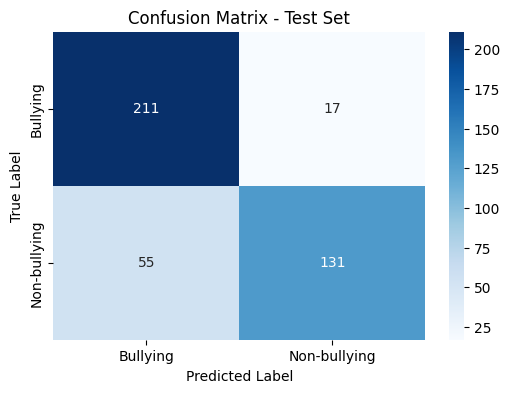

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================================
# 1. Prediction
# ================================
y_pred = final_model.predict(X_test_vec)

# ================================
# 2. Mapping Label (agar rapi)
# ================================
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (sorted by encoded_label):")
print(class_names)

# ================================
# 3. Evaluasi F1
# ================================
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# ================================
# 4. Classification Report
# ================================
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# ================================
# 5. Confusion Matrix + Heatmap
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [20]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.006274199485778809
📊 Throughput: 5100.252242940579 samples/sec
